# Importación de un modelo con datos de ventas de casas (housing.csv)

In [6]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')


# EDA completo siguiendo los modelos anteriores 
# Feature engineering 

In [7]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
156,5523000,6900,3,1,1,yes,yes,yes,no,no,0,yes,semi-furnished
349,3780000,4820,3,1,2,yes,no,no,no,no,0,no,semi-furnished
110,6090000,6600,3,1,1,yes,yes,yes,no,no,2,yes,semi-furnished
350,3780000,3420,2,1,2,yes,no,no,yes,no,1,no,semi-furnished
271,4340000,1905,5,1,2,no,no,yes,no,no,0,no,semi-furnished


In [8]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [9]:
df.tail(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [11]:
df.shape

(545, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [13]:
print('Existen ', df.isnull().sum().sum(),' valores no existentes')

Existen  0  valores no existentes


In [17]:
pd.set_option('display.float_format',lambda x:'%.1f'%x)

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4766729.2,1870439.6,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5150.5,2170.1,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,3.0,0.7,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.3,0.5,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.8,0.9,1.0,1.0,2.0,2.0,4.0
parking,545.0,0.7,0.9,0.0,0.0,0.0,1.0,3.0


In [19]:
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

In [20]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

# EDA completo siguiendo los modelos anteriores estandarización, eliminación, nuevas columnas.

In [21]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
361,3710000,6020,3,1,1,yes,no,no,no,no,0,no,semi-furnished
147,5600000,5500,3,2,2,yes,no,no,no,no,1,no,semi-furnished
118,5950000,6420,3,1,1,yes,no,yes,no,yes,0,yes,furnished
114,6020000,6800,2,1,1,yes,yes,yes,no,no,2,no,furnished
343,3850000,4080,2,1,1,yes,no,no,no,no,0,no,semi-furnished


In [22]:
df['mainroad'] = df['mainroad'].replace({'yes':1,'no':0},regex=True)
df['guestroom'] = df['guestroom'].replace({'yes':1,'no':0},regex=True)
df['basement'] = df['basement'].replace({'yes':1,'no':0},regex=True)
df['hotwaterheating'] = df['hotwaterheating'].replace({'yes':1,'no':0},regex=True)
df['airconditioning'] = df['airconditioning'].replace({'yes':1,'no':0},regex=True)
df['prefarea'] = df['prefarea'].replace({'yes':1,'no':0},regex=True)
df['furnishingstatus'] = df['furnishingstatus'].replace({'unfurnished':3,'semi-furnished':2,'furnished':1},regex=True)

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_69766/4235739201.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['mainroad'] = df['mainroad'].replace({'yes':1,'no':0},regex=True)
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_69766/4235739201.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['guestroom'] = df['guestroom'].replace({'yes':1,'no':0},regex=True)
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_69766/4235739201.py:3: FutureWarning: Downcasting behavior in `replace` is deprec

In [24]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
520,2450000,7700,2,1,1,1,0,0,0,0,0,0,3
476,2940000,5850,3,1,2,1,0,1,0,0,1,0,3
492,2800000,2650,3,1,2,1,0,1,0,0,1,0,3
430,3290000,2500,2,1,1,0,0,0,0,1,0,0,3
443,3220000,4320,3,1,1,0,0,0,0,0,1,0,3


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


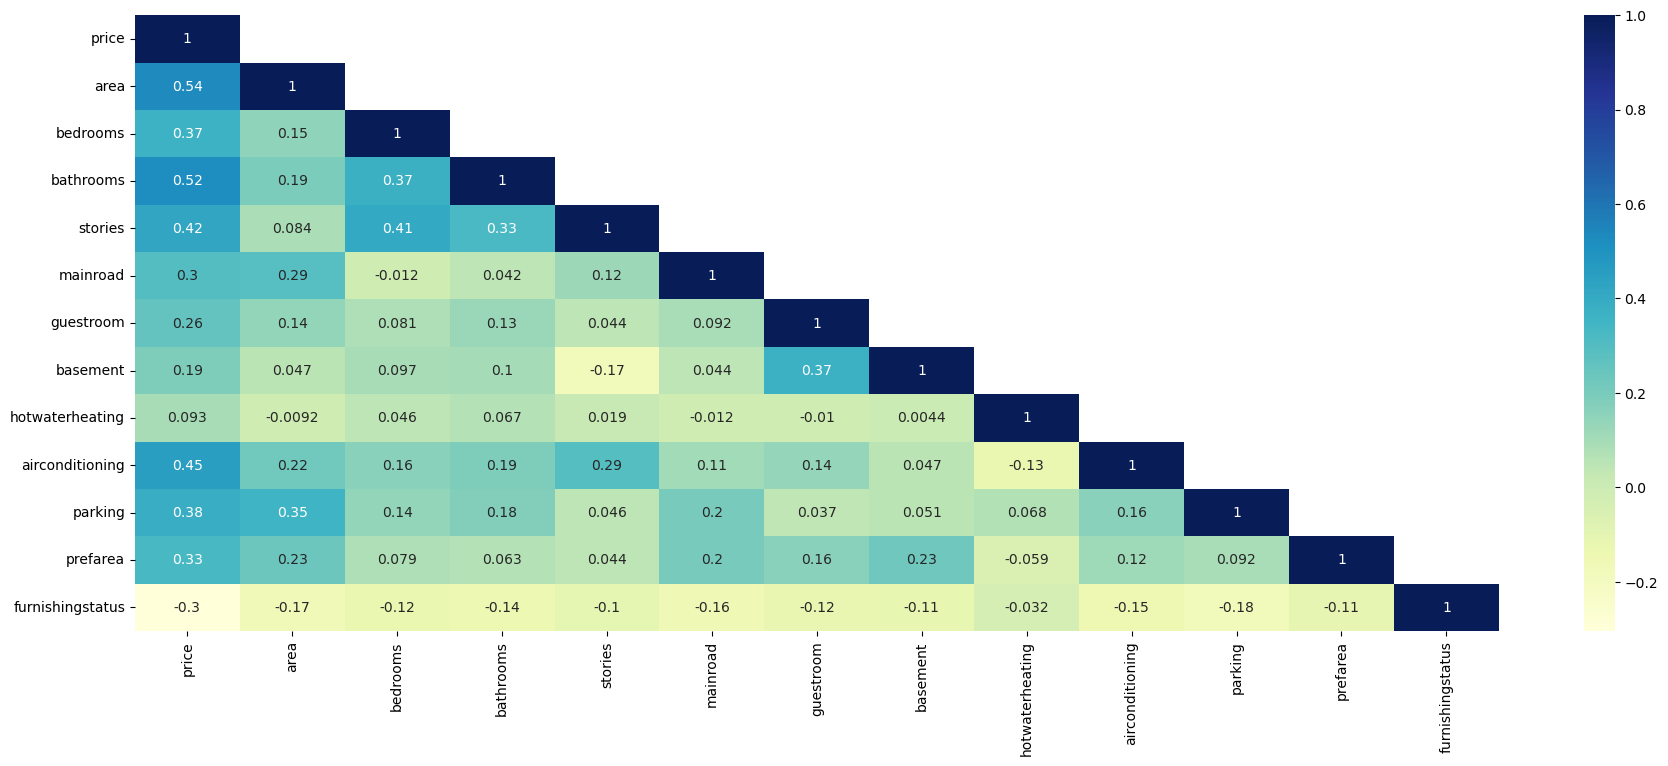

In [26]:
plt.figure(figsize=(22,8))
corr_df = corr = df.corr(method='pearson',numeric_only=True)
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap=sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

In [28]:
print('Lista completa de columnas')
print('---------------------------------------------------------------------------')
print(df.columns)
print(len(df.columns),' columnas')

cols_num = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus']

Lista completa de columnas
---------------------------------------------------------------------------
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
13  columnas


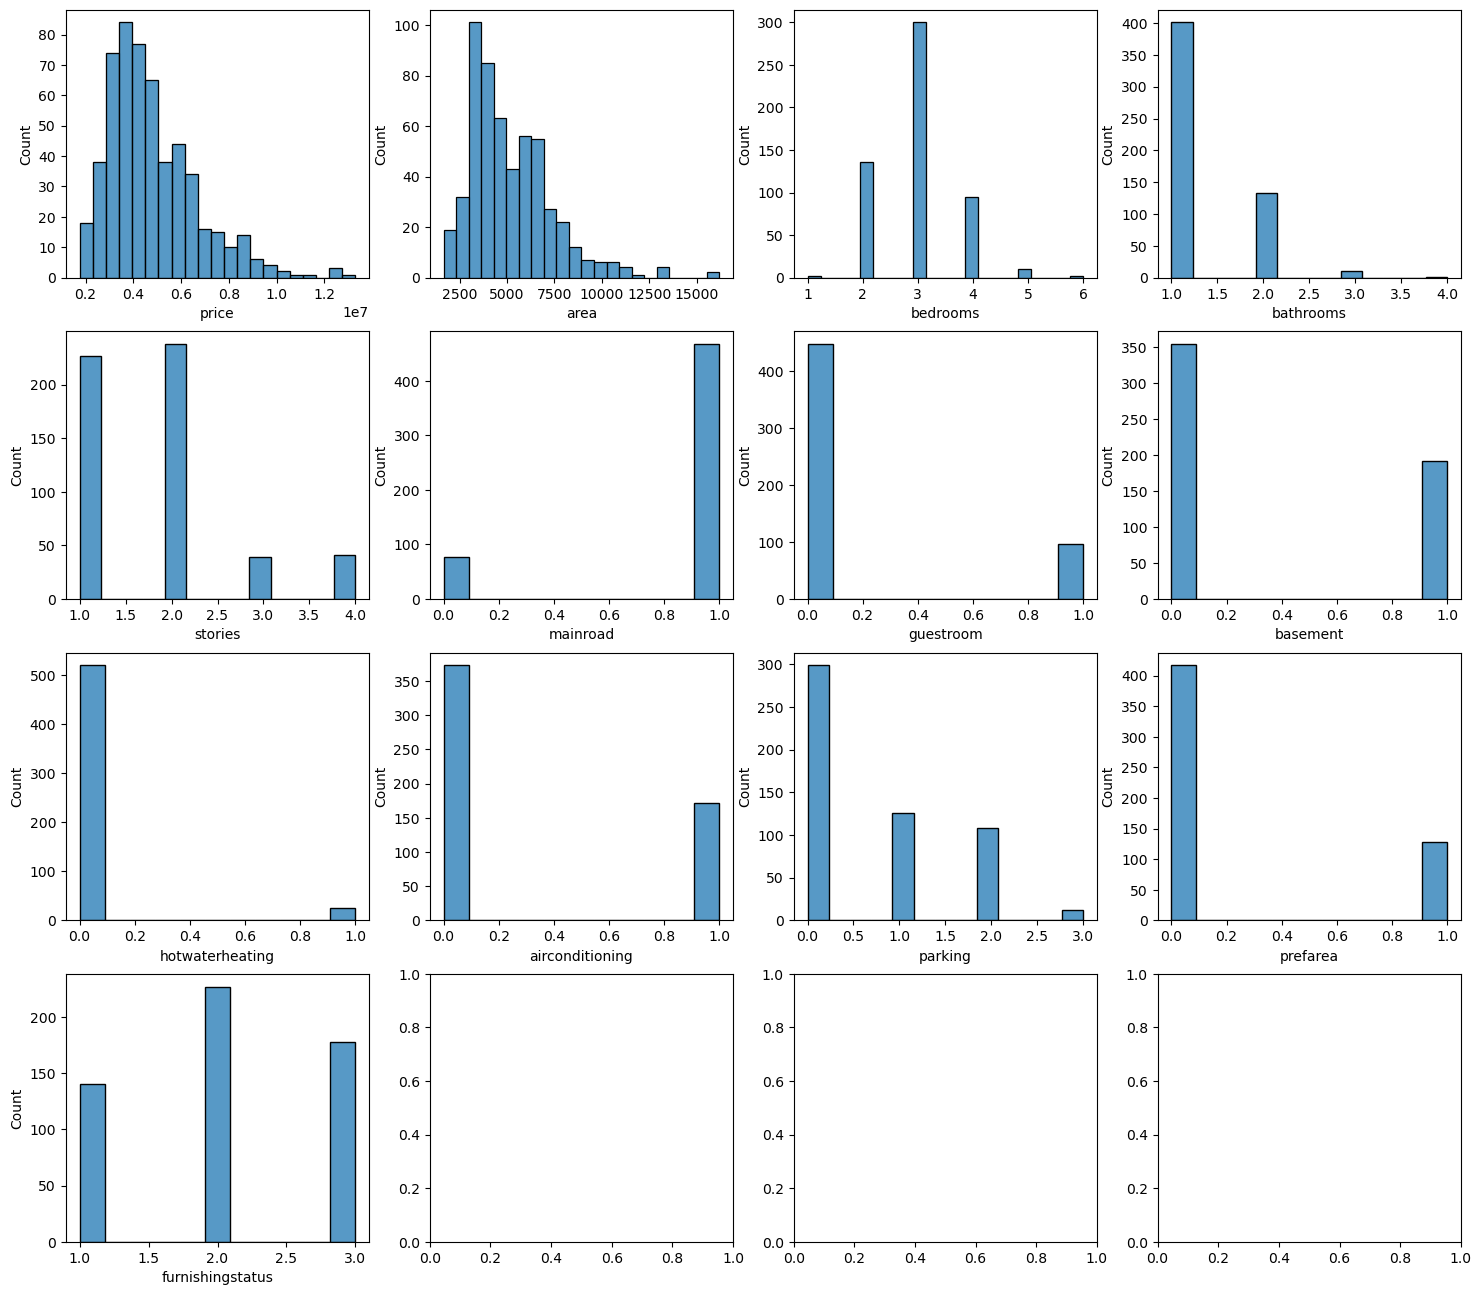

In [31]:
fig, axes = plt.subplots(nrows = 4 ,ncols=4, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//4,i%4],kde=False)

In [33]:
df.groupby('bedrooms').mean(numeric_only=True).T

bedrooms,1,2,3,4,5,6
price,2712500.0,3632022.1,4954598.1,5729757.9,5819800.0,4791500.0
area,3710.0,4636.2,5226.6,5582.1,6291.5,3950.0
bathrooms,1.0,1.1,1.3,1.6,1.8,1.5
stories,1.0,1.2,1.9,2.3,2.0,2.0
mainroad,0.5,0.9,0.9,0.9,0.6,1.0
guestroom,0.0,0.1,0.2,0.2,0.2,0.0
basement,0.0,0.2,0.4,0.4,0.6,0.0
hotwaterheating,0.0,0.0,0.0,0.0,0.2,0.0
airconditioning,0.0,0.2,0.4,0.4,0.3,0.0
parking,0.0,0.5,0.7,0.9,0.6,0.5


In [34]:
df.groupby('bedrooms').median(numeric_only=True).T

bedrooms,1,2,3,4,5,6
price,2712500.0,3535000.0,4620000.0,5250000.0,5582500.0,4791500.0
area,3710.0,4036.0,4830.0,5400.0,5350.0,3950.0
bathrooms,1.0,1.0,1.0,2.0,2.0,1.5
stories,1.0,1.0,2.0,2.0,2.0,2.0
mainroad,0.5,1.0,1.0,1.0,1.0,1.0
guestroom,0.0,0.0,0.0,0.0,0.0,0.0
basement,0.0,0.0,0.0,0.0,1.0,0.0
hotwaterheating,0.0,0.0,0.0,0.0,0.0,0.0
airconditioning,0.0,0.0,0.0,0.0,0.0,0.0
parking,0.0,0.0,0.0,1.0,0.0,0.5


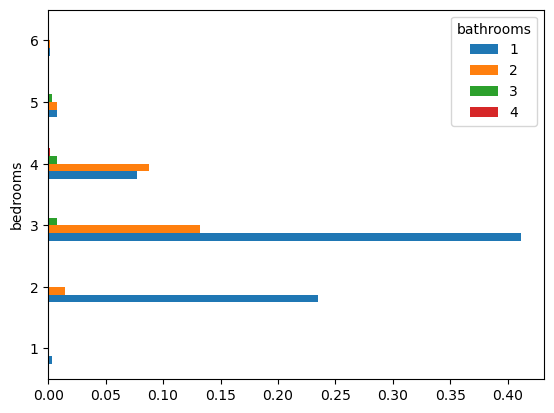

In [35]:
ct = pd.crosstab(df['bedrooms'],df['bathrooms'],normalize=True).plot.barh(stacked=False)

In [36]:
df.corr( numeric_only=True).style.background_gradient(cmap = 'Blues').set_properties(**{'front_size':'10px'})

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,-0.304721
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,-0.171445
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,-0.123244
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,-0.143559
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,-0.104672
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,-0.156726
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,-0.118328
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,-0.112831
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,-0.031628
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,-0.150477


# Generación de variables dummy en el set de datos 

# Aplicación de modelo de regresión lineal a la variable Price.

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [38]:
#df = df.dropna()
X = df.drop(['price'],axis=1)
y = df[['price']]

In [39]:
y.head()

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


# Entrenamiento, evaluación y predicción de los resultados del modelo.

In [61]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [62]:
X_train.head(3)

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
180,4500,4,2,1,0,0,1,0,1,2,0,2
189,3540,2,1,1,0,1,1,0,0,0,0,2
93,7200,3,2,1,1,0,1,0,1,3,0,2


In [63]:
regression_model = LinearRegression()

regression_model.fit(X_train,y_train)

LinearRegression()

In [64]:
regression_model.score(X_train,y_train)

0.6799674103626108

In [65]:
regression_model.score(X_test,y_test)

0.6621173401969211

# Análisis de Sensibilidad e importancia de variables.

# Visualización de los resultados del modelo de regresión

In [66]:
y_pred = regression_model.predict(X_test)

In [67]:
df_preds = pd.DataFrame({'Actual':y_test.squeeze(),'Predicted':y_pred.squeeze()})
print(df_preds)

      Actual  Predicted
62   7070000  6291567.1
247  4550000  6390833.3
142  5600000  6529768.6
107  6125000  5564502.0
483  2940000  4230599.3
..       ...        ...
450  3150000  4008865.1
542  1750000  2717347.4
408  3430000  2810959.6
80   6629000  5677214.5
46   7525000  7236802.7

[164 rows x 2 columns]


In [47]:
y_test

,price
62,7070000
247,4550000
142,5600000
107,6125000
483,2940000
...,...
450,3150000
542,1750000
408,3430000
80,6629000


In [48]:
y_pred

array([[6291567.10996267],
       [6390833.34559335],
       [6529768.57506302],
       [5564502.04961417],
       [4230599.25468818],
       [2914883.15196702],
       [2697427.73058359],
       [7414579.03096575],
       [2418919.9186991 ],
       [4441524.75205456],
       [3884060.72286849],
       [3622055.70318037],
       [4715571.50803798],
       [4646603.24223929],
       [5339291.00510066],
       [7883440.82703792],
       [4240649.49120762],
       [3506117.60103707],
       [6628569.39661572],
       [2724491.51868965],
       [4493770.53914978],
       [5250831.27677531],
       [5132091.19114307],
       [3465638.23219597],
       [5495990.74603413],
       [6960410.36950925],
       [2839348.31972912],
       [7452682.40876644],
       [7546627.45107944],
       [4358334.75954809],
       [7551419.47937435],
       [6757358.25271513],
       [4957722.1681115 ],
       [4672373.32162855],
       [6144998.34635488],
       [4595121.55499371],
       [6434412.29031045],
 

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = regression_model.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [50]:
print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root mean squared error: {rmse:.2f}')

Mean absolute error: 855894.77
Mean squared error: 1375329793553.13
Root mean squared error: 1172744.56


In [51]:
for idx, col_name in enumerate(X_train.columns):
    print('Coef {} = {}'.format(col_name,regression_model.coef_[0][idx]))

Coef area = 246.34768711251942
Coef bedrooms = 47198.862725111656
Coef bathrooms = 1020173.2432420903
Coef stories = 525778.9633518041
Coef mainroad = 476712.9848125422
Coef guestroom = 275668.9507600048
Coef basement = 557956.2675518359
Coef hotwaterheating = 822714.5575357177
Coef airconditioning = 608777.0120530989
Coef parking = 274736.44997549383
Coef prefarea = 500668.03295517794
Coef furnishingstatus = -202462.66994588563


In [52]:
coeff_data = pd.DataFrame({
    'Var': ['Intercept'] + list(X_train.columns),
    'Coeff': [regression_model.intercept_[0]] + list(regression_model.coef_[0])
})

coeff_data

,Var,Coeff
0,Intercept,315893.9
1,area,246.3
2,bedrooms,47198.9
3,bathrooms,1020173.2
4,stories,525779.0
5,mainroad,476713.0
6,guestroom,275669.0
7,basement,557956.3
8,hotwaterheating,822714.6
9,airconditioning,608777.0


In [53]:
Equation = 'Price = '
print(Equation, end='')

for i in range(len(coeff_data)):
    coeff = coeff_data.iloc[i]['Coeff']
    var = coeff_data.iloc[i]['Var']

    if i < len(coeff_data) - 1:
        print(f'({coeff}) * {var} + ', end='')
    else:
        print(f'({coeff}) * {var}')

Price = (315893.9013970634) * Intercept + (246.34768711251942) * area + (47198.862725111656) * bedrooms + (1020173.2432420903) * bathrooms + (525778.9633518041) * stories + (476712.9848125422) * mainroad + (275668.9507600048) * guestroom + (557956.2675518359) * basement + (822714.5575357177) * hotwaterheating + (608777.0120530989) * airconditioning + (274736.44997549383) * parking + (500668.03295517794) * prefarea + (-202462.66994588563) * furnishingstatus


Text(0.5, 1.0, 'Comparación de Predicción (x) vs Real (y)')

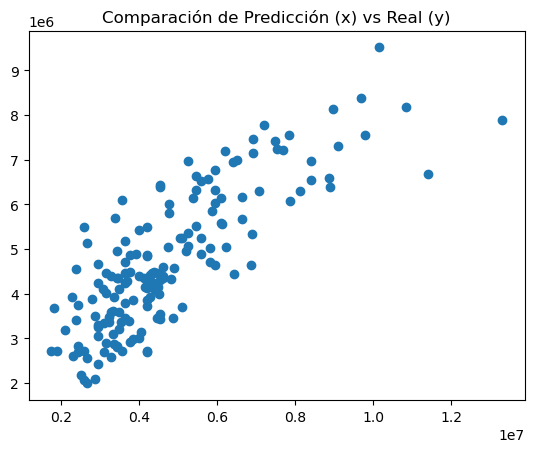

In [54]:
predictions = regression_model.predict(X_test)
plt.scatter(y_test,predictions)
plt.title('Comparación de Predicción (x) vs Real (y)')

Text(0.5, 1.0, 'Residuals')

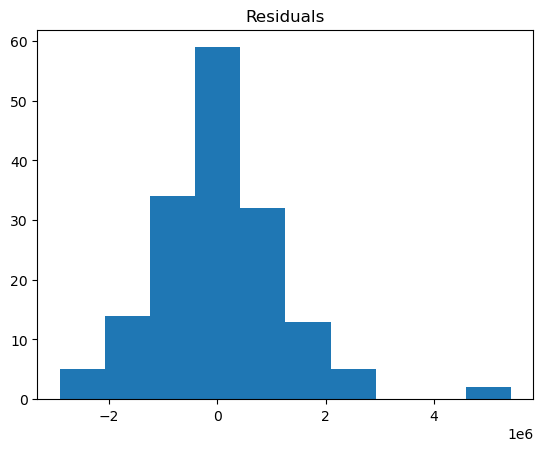

In [55]:
plt.hist(y_test - predictions)
plt.title('Residuals')

In [56]:
df.sample(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
384,3570000,4500,2,1,1,0,0,0,0,0,0,0,1
285,4235000,6650,3,1,2,1,1,0,0,0,0,0,2
255,4480000,5885,2,1,1,1,0,0,0,1,1,0,3
329,3990000,3960,3,1,2,1,0,0,0,0,0,0,1
50,7420000,7440,3,2,4,1,0,0,0,0,1,1,3
371,3640000,3570,3,1,2,1,0,1,0,0,0,0,2
217,4830000,6862,3,1,2,1,0,0,0,1,2,1,1
334,3920000,3290,2,1,1,1,0,0,1,0,1,0,1
298,4200000,5800,3,1,1,1,0,0,1,0,2,0,2
65,6930000,8880,3,2,2,1,0,1,0,1,1,0,1


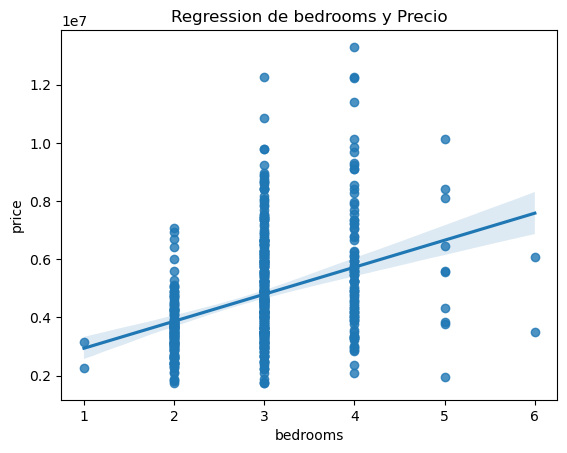

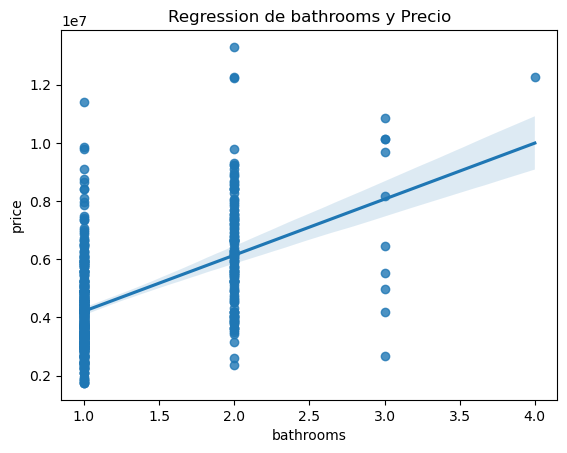

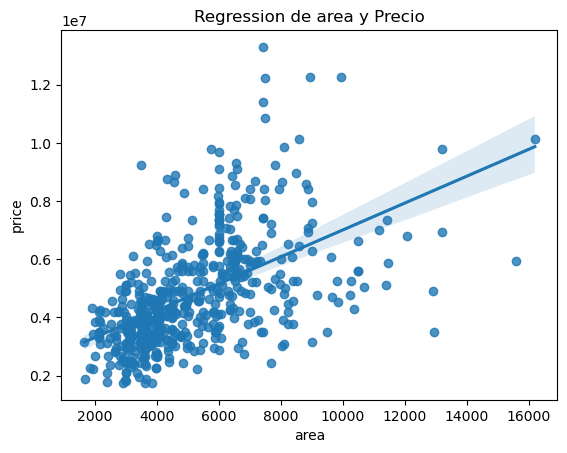

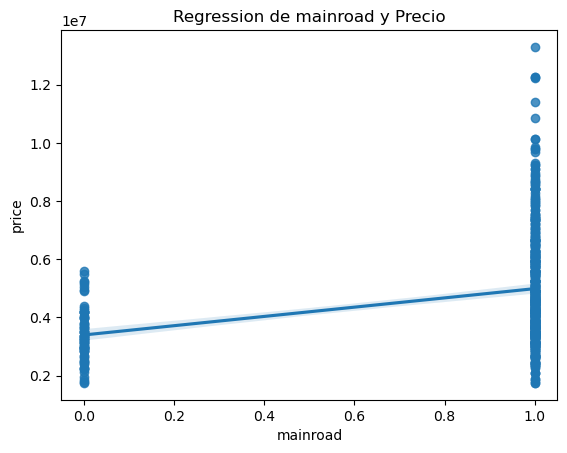

In [57]:
import seaborn as sns

variables = ['bedrooms','bathrooms','area','mainroad']

for var in variables:
    plt.figure()
    sns.regplot(x=var,y='price',data=df).set(title=f'Regression de {var} y Precio')

In [58]:
y_pred_df = pd.DataFrame(y_pred,columns = ['pred_price'])

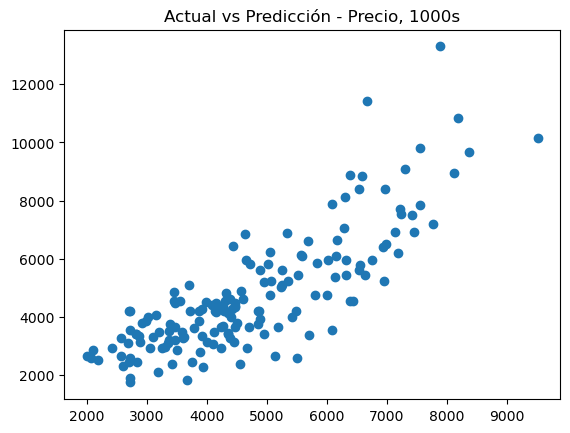

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.ticklabel_format(style='plain')
plt.title('Actual vs Predicción - Precio, 1000s')
plt.scatter(y_pred_df.pred_price/1000, y_test.price/1000)

In [60]:
import numpy as np

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score



In [99]:
# Imputación de valores faltantes

imputer = SimpleImputer(strategy='mean')

#df['X'] = imputer.fit_transform(df[['X']])

# Estandarización de los datos

scaler = StandardScaler()

#df['X'] = scaler.fit_transform(df[['X']])

In [101]:
#X = df[['X']] # Variable independiente

#y = df['y']  # Variable dependiente

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [102]:
model = LinearRegression()

model.fit(X_train, y_train)



LinearRegression()

In [103]:
# Coeficiente y ordenada al origen

print("Pendiente (coeficiente):", model.coef_[0])

print("Intercepción (ordenada al origen):", model.intercept_)

Pendiente (coeficiente): [-3.39786343e+04  4.00613404e+04  1.11652874e+02  1.67077578e-01
  7.29371164e+03  5.92965927e+05  4.82112563e+04  2.48215754e+04
  9.44901185e+04  6.96209770e+01  4.20318969e+01 -2.60423503e+03
  2.13716567e+01 -5.78201844e+02  6.08405265e+05 -2.21890368e+05
  2.13887506e+01 -3.52419057e-01]
Intercepción (ordenada al origen): [5110776.21542547]


In [104]:
y_pred = model.predict(X_test)

# Evaluación del modelo

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Error Cuadrático Medio (MSE):", mse)

print("R cuadrado:", r2)

Error Cuadrático Medio (MSE): 39194042530.05674
R cuadrado: 0.7153962762729047
